<a href="https://colab.research.google.com/github/NavanidhiDJ/6thSem-ML-Lab/blob/main/1BM23CS204_Lab_7_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy with default 10 trees: 1.0
Confusion Matrix (10 trees):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Best Accuracy Score: 1.0
Best Number of Trees: 1

Confusion Matrix (Best Model):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


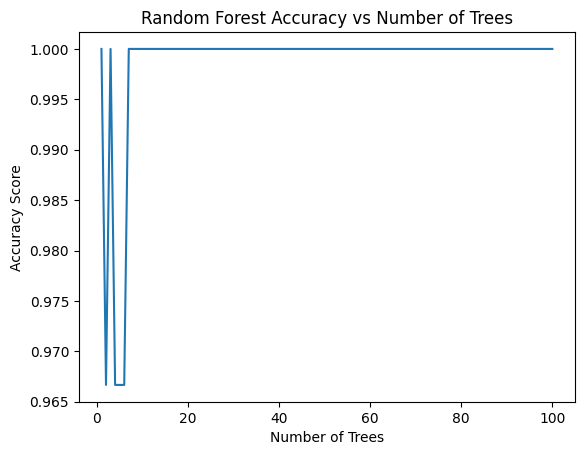

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

iris = pd.read_csv("iris.csv")

le = LabelEncoder()
iris["species"] = le.fit_transform(iris["species"])

X = iris.drop("species", axis=1)
y = iris["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy with default 10 trees:", accuracy_score(y_test, y_pred))
print("Confusion Matrix (10 trees):")
print(confusion_matrix(y_test, y_pred))


scores = []

tree_range = range(1,101)

for n in tree_range:

    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    scores.append(score)

best_score = max(scores)
best_trees = scores.index(best_score) + 1

print("\nBest Accuracy Score:", best_score)
print("Best Number of Trees:", best_trees)

rf = RandomForestClassifier(n_estimators=best_trees, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nConfusion Matrix (Best Model):")
print(confusion_matrix(y_test, y_pred))

plt.plot(tree_range, scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy Score")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.show()